# **06 — Segmentación y Descubrimiento de Patrones**
## Mercado Inmobiliario CABA · Fondo de Inversión

---

### Motivación analítica

Los análisis previos confirmaron que el mercado de CABA no es homogéneo. Sin embargo, las segmentaciones usadas hasta ahora (por comuna, por tipología, por zona de riesgo) son **categorías impuestas a priori** — no necesariamente capturan la estructura real del mercado desde el punto de vista del inversor.

El clustering permite **descubrir grupos naturales** en los datos respondiendo a: *¿existen perfiles de inversión diferenciados en el mercado de departamentos de CABA, y cuáles son accionables para el fondo?*

**Por qué usar los componentes PCA del notebook 05 como input:**
1. Reducen el espacio a 4 dimensiones, evitando *curse of dimensionality* sobre los 9 features originales.
2. Componentes ortogonales por construcción — la distancia euclidiana tiene sentido geométrico.
3. Los 4 componentes capturan **63.9% de varianza** (ver nb05); el resto es ruido idiosincrático o efectos no lineales que PCA no modela. Los clusters deben leerse contra los perfiles agregados de cada cluster (medianas por variable original), no solo contra los componentes.

> El FA fue descartado en nb05 por KMO inadecuado; ver §5 de ese notebook. PCA no requiere ese test.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

print("Setup completado ✓")

Setup completado ✓


## 1. Carga del dataset con componentes PCA


In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
URL_SCORES = ('https://raw.githubusercontent.com/kiaranatale/'
              'Trabajo-Practico-Real-State-Analytics/refs/heads/main/'
              'Datos2/dataset_ventas_pca_scores.csv')
try:
    df = pd.read_csv(URL_SCORES)
    print("Cargado desde GitHub ✓")
except Exception:
    df = pd.read_csv('/content/dataset_ventas_pca_scores.csv')
    print("Cargado desde archivo local ✓")

SCORE_COLS = [c for c in df.columns if c.startswith('PC') and c[2:].isdigit()]

num_cols = ['Precio_m2_USD','Rentabilidad_bruta_anual','Rentabilidad_neta_anual',
            'Payback_anios','Yield_gap_vs_bonos','Indice_amenities','Sup_Cubierta_m2',
            'Distancia_subte_km','Tasa_delitos_comuna','Liquidez_oferta_comuna','Comuna']
for c in num_cols + SCORE_COLS:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

df_scores = df[SCORE_COLS].dropna()
X = df_scores.values

print(f"Shape total: {df.shape}")
print(f"Filas con scores completos (input clustering): {len(df_scores):,}")
print(f"Score columns: {SCORE_COLS}")

Cargado desde archivo local ✓
Shape total: (3140, 22)
Filas con scores completos (input clustering): 3,140
Score columns: ['PC1', 'PC2', 'PC3', 'PC4']


## 2. Justificación de variables y algoritmo

### Variables de clustering

Los **4 componentes principales** del PCA del nb05. Cada componente es una combinación lineal estandarizada y ortogonal de las 9 variables del análisis (precio/m², superficie, distancias a subte y parque, liquidez, tasa de delitos, volatilidad, amenities, rentabilidad). La interpretación sustantiva de cada componente surge de sus loadings — ver 7. del nb05.

**Resumen rápido de los ejes:**
- **PC1 — Valor de mercado** (21% var): precio/m² + amenities ↔ rentabilidad.
- **PC2 — Accesibilidad urbana** (17.8% var): distancias a subte/parque ↔ liquidez.
- **PC3 — Riesgo contextual** (13.5% var): volatilidad + delitos ↔ centralidad.
- **PC4 — Tamaño** (11.6% var): superficie como dimensión ortogonal independiente.

**Importante:** dado que el PCA acá explica el 63.9% de la varianza (resto = ruido idiosincrático), los centroides en el espacio PC no son por sí solos interpretables. El perfil de cada cluster se construye con los **agregados sobre las variables originales** (medianas por cluster).

### Elección de K-Means

K-Means es apropiado para este dataset por tres razones:
1. **Escala**: ~3.000 observaciones en 4 dimensiones — K-Means es estable y eficiente.
2. **Espacio de componentes**: los componentes PCA son ortogonales por construcción, lo que estabiliza la distancia euclidiana que asume K-Means.
3. **Interpretabilidad operativa**: los centroides son posiciones en el espacio reducido; los perfiles comerciales se leen de los agregados por cluster sobre variables originales.

Como validación independiente corremos **clustering jerárquico Ward** para confirmar que los grupos encontrados reflejan estructura real del mercado y no un artefacto del algoritmo.


## 3. Determinación del número de clusters

Tres métricas complementarias. La decisión final balancea las métricas con la **interpretabilidad comercial** de los segmentos.


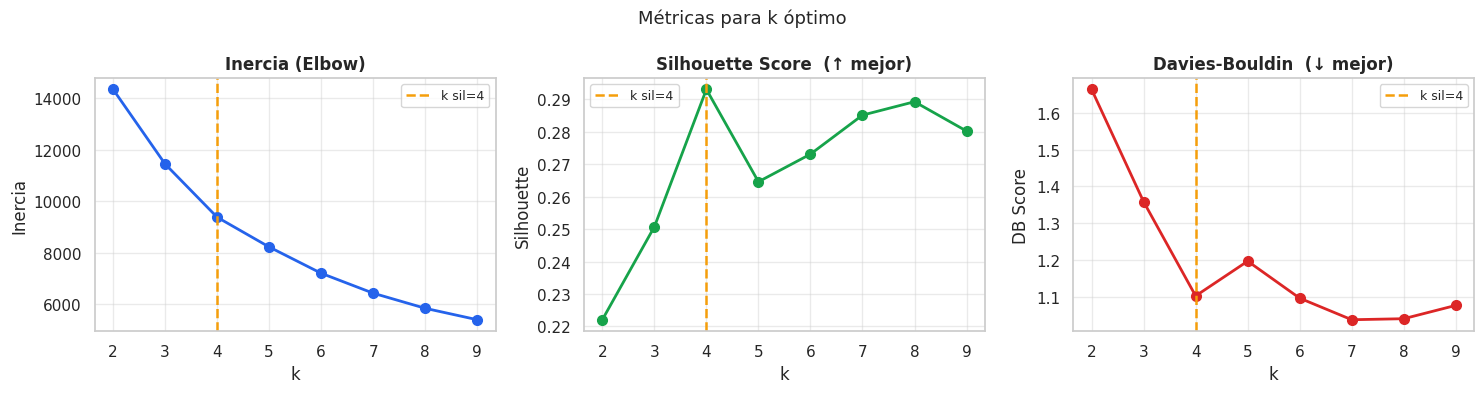

   k     Inercia    Silhouette    Davies-Bouldin
  2      14352.9        0.2221            1.6631
  3      11449.9        0.2507            1.3584
  4       9381.8        0.2930            1.1032 ←
  5       8225.2        0.2646            1.1974
  6       7203.1        0.2731            1.0970
  7       6428.6        0.2851            1.0386
  8       5840.9        0.2892            1.0414
  9       5397.2        0.2802            1.0775


In [22]:
k_range = range(2, 10)
inercias, silhouettes, db_scores = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels, random_state=42))
    db_scores.append(davies_bouldin_score(X, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_range, inercias, 'o-', color='#2563eb', lw=2, ms=7)
axes[0].set(title='Inercia (Elbow)', xlabel='k', ylabel='Inercia')
axes[0].grid(alpha=0.4)

axes[1].plot(k_range, silhouettes, 'o-', color='#16a34a', lw=2, ms=7)
axes[1].set(title='Silhouette Score  (↑ mejor)', xlabel='k', ylabel='Silhouette')
axes[1].grid(alpha=0.4)

axes[2].plot(k_range, db_scores, 'o-', color='#dc2626', lw=2, ms=7)
axes[2].set(title='Davies-Bouldin  (↓ mejor)', xlabel='k', ylabel='DB Score')
axes[2].grid(alpha=0.4)

k_sil = silhouettes.index(max(silhouettes)) + 2
k_db  = db_scores.index(min(db_scores)) + 2
for ax in axes:
    ax.axvline(k_sil, color='#f59e0b', ls='--', lw=1.8, label=f'k sil={k_sil}')
    ax.legend(fontsize=9)

plt.suptitle('Métricas para k óptimo', fontsize=13)
plt.tight_layout()
plt.show()

print(f"{'k':>4}  {'Inercia':>10}  {'Silhouette':>12}  {'Davies-Bouldin':>16}")
for i, k in enumerate(k_range):
    mark = " ←" if k == k_sil else ""
    print(f"  {k}   {inercias[i]:>10.1f}  {silhouettes[i]:>12.4f}  {db_scores[i]:>16.4f}{mark}")

**Hallazgo clave — número de clusters:** la silhouette máxima se da en **k=4** (0.29).
Davies-Bouldin tiene un mínimo marginal en k=7 (1.039 vs 1.103 en k=4) pero la diferencia
es pequeña y k=7 implicaría fragmentar el mercado en segmentos demasiado finos para ser
accionables. **Elegimos k=4** priorizando silhouette + interpretabilidad comercial.

**Sobre la cohesión de los clusters:** silhouette = 0.29 y DB = 1.10 indican clusters con
solapamiento moderado — no hay separación nítida entre segmentos. Esto es **esperado y
consistente** con los resultados del nb05: el PCA explicó 63.9% de varianza con correlaciones
intervariables bajas (KMO = 0.42), lo que implica que el mercado inmobiliario de CABA no
está naturalmente compartimentado en grupos discretos. Los clusters capturan tendencias
centrales diferenciadas, no segmentos estancos. La interpretación comercial debe leerse con
esta limitación: una propiedad en la frontera entre clusters puede pertenecer a cualquiera
de los dos con propiedades similares.

In [23]:
# ── Constante del pipeline ────────────────────────────────────────────────────
K_FINAL = 4  # Ajustar con justificación si las métricas anteriores apuntan a distinto k

km_final = KMeans(n_clusters=K_FINAL, init='k-means++', n_init=50, random_state=42)
labels = km_final.fit_predict(X)

sil = silhouette_score(X, labels, random_state=42)
db  = davies_bouldin_score(X, labels)
ch  = calinski_harabasz_score(X, labels)

print(f"K-Means final  k={K_FINAL}")
print(f"  Silhouette:     {sil:.4f}  (referencia: >0.50 bueno)")
print(f"  Davies-Bouldin: {db:.4f}  (referencia: <1.0 bueno)")
print(f"  Calinski-H:     {ch:.1f}")
print()
print("Distribución:")
for cid in sorted(np.unique(labels)):
    n = sum(labels == cid)
    print(f"  Cluster {cid}: {n:,} props  ({n/len(labels)*100:.1f}%)")

df.loc[df_scores.index, 'Cluster'] = labels.astype(int)
df['Cluster'] = df['Cluster'].fillna(-1).astype(int)

K-Means final  k=4
  Silhouette:     0.2936  (referencia: >0.50 bueno)
  Davies-Bouldin: 1.1027  (referencia: <1.0 bueno)
  Calinski-H:     967.7

Distribución:
  Cluster 0: 546 props  (17.4%)
  Cluster 1: 1,172 props  (37.3%)
  Cluster 2: 1,259 props  (40.1%)
  Cluster 3: 163 props  (5.2%)


## 4. Validación: clustering jerárquico Ward

La consistencia entre K-Means y Ward confirma que los grupos reflejan estructura real del mercado.


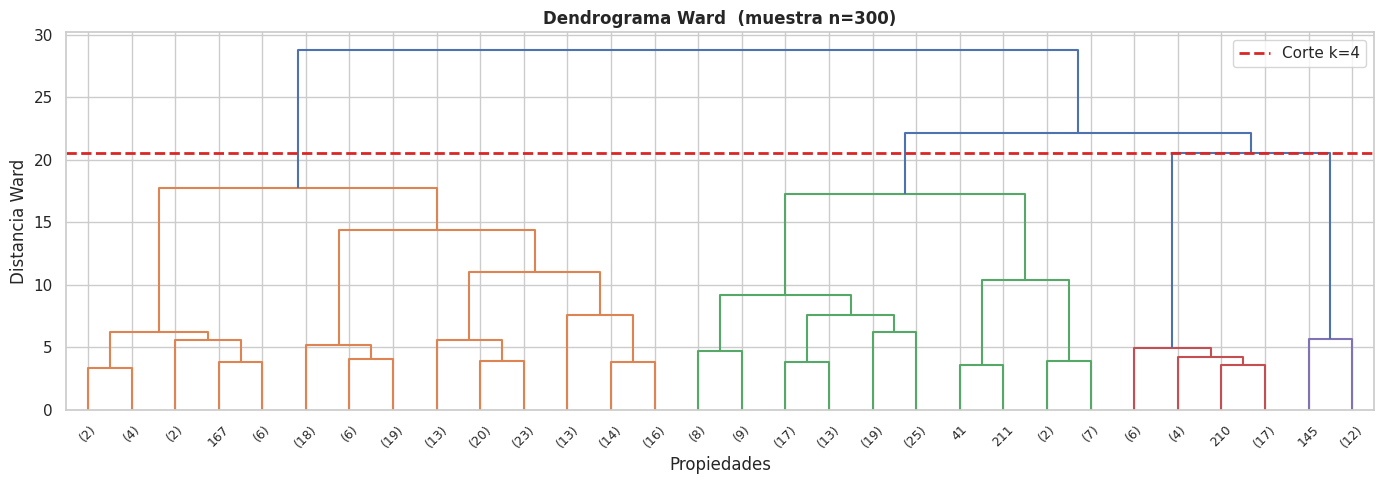

Silhouette K-Means (n total):    0.2936
Silhouette Ward    (n muestra):  0.2949
→ Consistencia entre métodos confirma robustez de la estructura.


In [24]:
np.random.seed(42)
idx_sample = np.random.choice(len(X), min(300, len(X)), replace=False)
Z = linkage(X[idx_sample], method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=45, leaf_font_size=9,
           color_threshold=Z[-K_FINAL+1, 2])
ax.axhline(Z[-K_FINAL+1, 2], color='#dc2626', ls='--', lw=2, label=f'Corte k={K_FINAL}')
ax.set(title=f'Dendrograma Ward  (muestra n={len(idx_sample)})',
       xlabel='Propiedades', ylabel='Distancia Ward')
ax.legend()
plt.tight_layout()
plt.show()

labels_ward = fcluster(Z, K_FINAL, criterion='maxclust') - 1
sil_ward = silhouette_score(X[idx_sample], labels_ward)
print(f"Silhouette K-Means (n total):    {sil:.4f}")
print(f"Silhouette Ward    (n muestra):  {sil_ward:.4f}")
print("→ Consistencia entre métodos confirma robustez de la estructura.")

## 5. Perfil de los clusters

Calculamos medianas por cluster para construir el perfil comercial de cada segmento. Las medianas son robustas ante outliers — más representativas que las medias en distribuciones asimétricas como las del mercado inmobiliario.


In [25]:
df_clust = df[df['Cluster'] >= 0].copy()

PERFIL_VARS = ['Precio_m2_USD','Rentabilidad_bruta_anual','Rentabilidad_neta_anual',
               'Payback_anios','Yield_gap_vs_bonos','Sup_Cubierta_m2','Indice_amenities',
               'Distancia_subte_km','Tasa_delitos_comuna','Liquidez_oferta_comuna']
perfil_exist = [v for v in PERFIL_VARS + SCORE_COLS if v in df_clust.columns]

perfil = df_clust.groupby('Cluster')[perfil_exist].median().round(3)
perfil.insert(0, 'N', df_clust.groupby('Cluster').size())
perfil.insert(1, '%', (df_clust.groupby('Cluster').size()/len(df_clust)*100).round(1))

print("PERFIL MEDIANO DE LOS CLUSTERS")
print("="*75)
print(perfil.T.to_string())

PERFIL MEDIANO DE LOS CLUSTERS
Cluster                          0         1         2         3
N                          546.000 1,172.000 1,259.000   163.000
%                           17.400    37.300    40.100     5.200
Precio_m2_USD            2,320.589 2,000.000 3,132.885 2,482.759
Rentabilidad_bruta_anual     0.064     0.078     0.053     0.054
Rentabilidad_neta_anual      0.027     0.040     0.017     0.018
Payback_anios               15.677    12.895    18.987    18.609
Yield_gap_vs_bonos          -0.036    -0.022    -0.047    -0.046
Sup_Cubierta_m2             50.000    51.850    51.000    54.000
Indice_amenities             1.000     1.000     2.000     1.000
Distancia_subte_km           2.265     0.508     0.717     0.974
Tasa_delitos_comuna          0.482     0.933     0.324     0.579
Liquidez_oferta_comuna       0.001     0.001     0.002     0.001
PC1                         -0.376    -0.851     0.964    -0.436
PC2                          1.634    -0.614    -0.603     

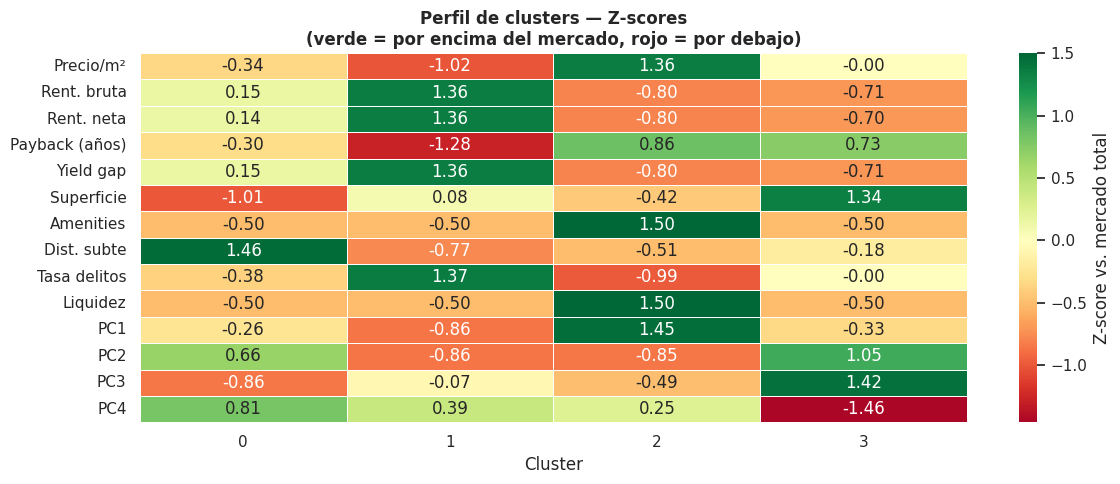

In [26]:
# ── Heatmap de perfil normalizado ────────────────────────────────────────────
perfil_num = perfil.drop(columns=['N','%'])
perfil_norm = (perfil_num - perfil_num.mean()) / perfil_num.std()

ETIQ = {'Precio_m2_USD':'Precio/m²','Rentabilidad_bruta_anual':'Rent. bruta',
        'Rentabilidad_neta_anual':'Rent. neta','Payback_anios':'Payback (años)',
        'Yield_gap_vs_bonos':'Yield gap','Sup_Cubierta_m2':'Superficie',
        'Indice_amenities':'Amenities','Distancia_subte_km':'Dist. subte',
        'Tasa_delitos_comuna':'Tasa delitos','Liquidez_oferta_comuna':'Liquidez'}
perfil_norm = perfil_norm.rename(columns=ETIQ)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(perfil_norm.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'label':'Z-score vs. mercado total'}, ax=ax)
ax.set_title('Perfil de clusters — Z-scores\n(verde = por encima del mercado, rojo = por debajo)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

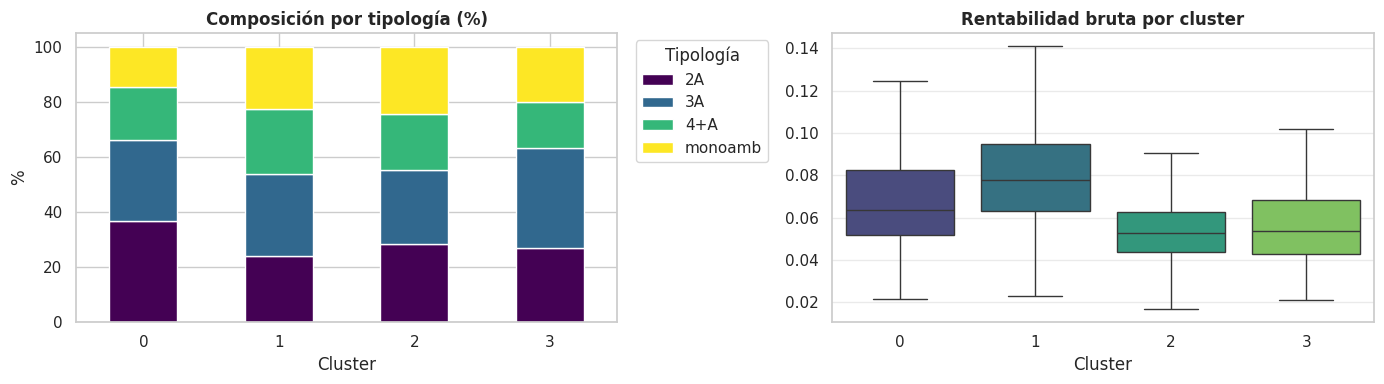

In [27]:
# ── Composición tipológica ────────────────────────────────────────────────────
if 'Tipologia' in df_clust.columns:
    tip_pct = (df_clust.groupby(['Cluster','Tipologia']).size()
               .unstack(fill_value=0)
               .pipe(lambda d: d.div(d.sum(axis=1), axis=0)) * 100).round(1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    tip_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis', edgecolor='white')
    axes[0].set(title='Composición por tipología (%)', xlabel='Cluster', ylabel='%')
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].legend(title='Tipología', bbox_to_anchor=(1.02,1))

    # Boxplot rentabilidad por cluster
    sns.boxplot(data=df_clust, x='Cluster', y='Rentabilidad_bruta_anual',
                palette='viridis', showfliers=False, ax=axes[1],
                order=sorted(df_clust['Cluster'].unique()))
    axes[1].set(title='Rentabilidad bruta por cluster', xlabel='Cluster', ylabel='')
    axes[1].grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()

In [28]:
# ── Scatter 3D interactivo ────────────────────────────────────────────────────
if len(SCORE_COLS) >= 3:
    df_plot = df_clust.dropna(subset=SCORE_COLS[:3]).copy()
    df_plot['Seg'] = 'Cluster ' + df_plot['Cluster'].astype(str)
    hover = [c for c in ['Precio_m2_USD','Rentabilidad_bruta_anual','Tipologia','Barrio']
             if c in df_plot.columns]
    fig = px.scatter_3d(df_plot, x=SCORE_COLS[0], y=SCORE_COLS[1], z=SCORE_COLS[2],
                         color='Seg', hover_data=hover, opacity=0.55,
                         title='Clusters en el espacio de componentes (PC1–PC3 de 4)',
                         labels={SCORE_COLS[0]:'PC1 — Valor de mercado',
                                 SCORE_COLS[1]:'PC2 — Accesibilidad',
                                 SCORE_COLS[2]:'PC3 — Riesgo contextual'},
                         color_discrete_sequence=px.colors.qualitative.Bold)
    # Centroides
    for i, c in enumerate(km_final.cluster_centers_):
        fig.add_trace(go.Scatter3d(x=[c[0]],y=[c[1]],z=[c[2]], mode='markers+text',
                                    marker=dict(size=11,symbol='diamond',color='black'),
                                    text=[f'C{i}'], textposition='top center',
                                    name=f'Centroide {i}', showlegend=False))
    fig.update_layout(height=540, template='plotly_white')
    fig.show()

## 6. Interpretación comercial de los segmentos


In [29]:
# ── Nombres post-hoc derivados del perfil real (no hardcodeados) ─────────────
# Etiquetamos cada cluster por sus rasgos distintivos sobre la mediana del mercado.
rent_med_mkt = df_clust['Rentabilidad_bruta_anual'].median()
pm2_med_mkt  = df_clust['Precio_m2_USD'].median()
liq_med_mkt  = df_clust['Liquidez_oferta_comuna'].median()

NOMBRES = {}
for cid in sorted(df_clust['Cluster'].unique()):
    sub = df_clust[df_clust['Cluster'] == cid]
    rent = sub['Rentabilidad_bruta_anual'].median()
    pm2  = sub['Precio_m2_USD'].median()
    liq  = sub['Liquidez_oferta_comuna'].median()
    zona_dom = sub['Zona_riesgo'].value_counts().idxmax() if 'Zona_riesgo' in sub.columns else ''
    tip_dom  = sub['Tipologia'].value_counts().idxmax()  if 'Tipologia'  in sub.columns else ''
    # Reglas simples basadas en la posición vs. mercado
    if pm2 > pm2_med_mkt * 1.15 and liq >= liq_med_mkt:
        nombre = "Premium consolidado (corredor norte)"
    elif rent > rent_med_mkt * 1.10 and zona_dom == 'alto':
        nombre = "Alto riesgo / alta rentabilidad"
    elif rent > rent_med_mkt:
        nombre = f"Rentabilidad sobre mercado ({tip_dom})"
    else:
        nombre = f"Rentabilidad bajo mercado ({tip_dom}, {zona_dom})"
    NOMBRES[cid] = nombre

print("INTERPRETACIÓN COMERCIAL DE LOS SEGMENTOS")
print("="*70)
for cid in sorted(df_clust['Cluster'].unique()):
    sub = df_clust[df_clust['Cluster'] == cid]
    print(f"\nCLUSTER {cid} — {NOMBRES.get(cid, 'Por caracterizar')}  (n={len(sub):,})")
    for var, label, fmt in [
        ('Precio_m2_USD',           'Precio/m² mediano',          '{:,.0f} USD/m²'),
        ('Rentabilidad_bruta_anual','Rentabilidad bruta mediana',  '{:.2%}'),
        ('Payback_anios',           'Payback mediano',             '{:.1f} años'),
        ('Yield_gap_vs_bonos',      'Yield gap vs bonos',          '{:+.2%}'),
        ('Liquidez_oferta_comuna',  'Liquidez oferta (mediana)',   '{:.4f}'),
    ]:
        if var in sub.columns:
            v = sub[var].median()
            print(f"  {label:35s}: {fmt.format(v)}")
    if 'Tipologia' in sub.columns:
        print(f"  {'Tipología dominante':35s}: {sub['Tipologia'].value_counts().idxmax()}")
    if 'Zona_riesgo' in sub.columns:
        print(f"  {'Zona de riesgo dominante':35s}: {sub['Zona_riesgo'].value_counts().idxmax()}")
    if 'Barrio' in sub.columns:
        top = sub['Barrio'].value_counts().head(3).index.tolist()
        print(f"  {'Top 3 barrios':35s}: {', '.join(str(b) for b in top)}")

INTERPRETACIÓN COMERCIAL DE LOS SEGMENTOS

CLUSTER 0 — Rentabilidad sobre mercado (2A)  (n=546)
  Precio/m² mediano                  : 2,321 USD/m²
  Rentabilidad bruta mediana         : 6.38%
  Payback mediano                    : 15.7 años
  Yield gap vs bonos                 : -3.62%
  Liquidez oferta (mediana)          : 0.0008
  Tipología dominante                : 2A
  Zona de riesgo dominante           : medio
  Top 3 barrios                      : Flores, Saavedra, Nuñez

CLUSTER 1 — Alto riesgo / alta rentabilidad  (n=1,172)
  Precio/m² mediano                  : 2,000 USD/m²
  Rentabilidad bruta mediana         : 7.76%
  Payback mediano                    : 12.9 años
  Yield gap vs bonos                 : -2.24%
  Liquidez oferta (mediana)          : 0.0015
  Tipología dominante                : 3A
  Zona de riesgo dominante           : alto
  Top 3 barrios                      : Recoleta, Caballito, Almagro

CLUSTER 2 — Premium consolidado (corredor norte)  (n=1,259)
  Preci

## 7. Evaluación de accionabilidad

Un segmento será considerado **accionable** para el fondo si cumple dos condiciones simultáneamente:
1. **Rentabilidad diferencial**: yield bruto supera la mediana del mercado o el bono soberano USD (10%).
2. **Escalabilidad**: liquidez comunal ≥ mediana — hay suficiente oferta para desplegar capital.


In [30]:
# Yield bono soberano AR USD (rango histórico 2024-2025: 8-12%).
# Se usa 10% como punto medio conservador ante la ausencia del dato exacto
# a fecha de scraping. Sensibilidad: un cambio de ±2pp modifica la clasificación
# de accionabilidad vs bono pero no vs mercado.
YIELD_BONO = 0.10
rent_mediana = df_clust['Rentabilidad_bruta_anual'].median()
liq_p50      = df_clust['Liquidez_oferta_comuna'].median()

In [31]:
print("EVALUACIÓN DE ACCIONABILIDAD")
print("="*60)
print(f"Benchmark rentabilidad mediana mercado: {rent_mediana:.2%}")
print(f"Benchmark yield bono soberano USD:      {YIELD_BONO:.0%}  (aprox. conservadora 2024-2025)")
print(f"Umbral liquidez (mediana absoluta):     {liq_p50:.4f}")
print()

for cid in sorted(df_clust['Cluster'].unique()):
    sub = df_clust[df_clust['Cluster'] == cid]

    rent = sub['Rentabilidad_bruta_anual'].median() if 'Rentabilidad_bruta_anual' in sub.columns else np.nan
    liq  = sub['Liquidez_oferta_comuna'].median()   if 'Liquidez_oferta_comuna'   in sub.columns else np.nan

    sup_mercado = not np.isnan(rent) and rent > rent_mediana
    sup_bono    = not np.isnan(rent) and rent > YIELD_BONO
    escalable   = not np.isnan(liq)  and liq >= liq_p50

    # Se evalúan dos condiciones de accionabilidad independientes:
    # vs mercado: supera la mediana del mercado inmobiliario + tiene liquidez
    # vs bono:    supera el activo alternativo de referencia + tiene liquidez
    # Un cluster puede ser accionable en un sentido y no en el otro.
    accionable_vs_mercado = sup_mercado and escalable
    accionable_vs_bono    = sup_bono    and escalable

    print(f"Cluster {cid} — {NOMBRES.get(cid, '')}")
    print(f"  Rent. bruta mediana:              {rent:.2%}")
    print(f"  vs mediana mercado ({rent_mediana:.2%}):   {'↑ supera' if sup_mercado else '↓ bajo'}")
    print(f"  vs bono USD ({YIELD_BONO:.0%}):             {'↑ supera' if sup_bono    else '↓ bajo'}")
    print(f"  Liquidez absoluta:                {liq:.4f}  (umbral p50: {liq_p50:.4f})")
    print(f"  Escalable (liq ≥ p50):            {'✓' if escalable else '✗'}")
    print(f"  → Accionable vs mercado:          {'✅ SÍ' if accionable_vs_mercado else '⚠  NO'}")
    print(f"  → Accionable vs bono:             {'✅ SÍ' if accionable_vs_bono    else '⚠  NO'}")
    print()

EVALUACIÓN DE ACCIONABILIDAD
Benchmark rentabilidad mediana mercado: 6.21%
Benchmark yield bono soberano USD:      10%  (aprox. conservadora 2024-2025)
Umbral liquidez (mediana absoluta):     0.0017

Cluster 0 — Rentabilidad sobre mercado (2A)
  Rent. bruta mediana:              6.38%
  vs mediana mercado (6.21%):   ↑ supera
  vs bono USD (10%):             ↓ bajo
  Liquidez absoluta:                0.0008  (umbral p50: 0.0017)
  Escalable (liq ≥ p50):            ✗
  → Accionable vs mercado:          ⚠  NO
  → Accionable vs bono:             ⚠  NO

Cluster 1 — Alto riesgo / alta rentabilidad
  Rent. bruta mediana:              7.76%
  vs mediana mercado (6.21%):   ↑ supera
  vs bono USD (10%):             ↓ bajo
  Liquidez absoluta:                0.0015  (umbral p50: 0.0017)
  Escalable (liq ≥ p50):            ✗
  → Accionable vs mercado:          ⚠  NO
  → Accionable vs bono:             ⚠  NO

Cluster 2 — Premium consolidado (corredor norte)
  Rent. bruta mediana:              5.27%

**Hallazgo clave — accionabilidad:**

Ningún cluster cumple simultáneamente las dos condiciones de accionabilidad bajo ninguno
de los dos benchmarks. Este resultado no es un artefacto del análisis sino una conclusión
sustantiva sobre el mercado inmobiliario de CABA en 2025.

**Por qué ninguno supera el bono:** la rentabilidad bruta mediana del mercado es 6.21%,
muy por debajo del rendimiento del bono soberano argentino en USD (~10%). El alquiler
tradicional en CABA no compite con el activo alternativo de referencia en términos de
yield bruto. Para el fondo, esto implica que la inversión inmobiliaria solo se justifica
si se incorporan otros componentes de retorno: apreciación del capital, reducción de
volatilidad de portafolio, o alquiler temporal (H6 validó una prima de ~37% sobre el
alquiler tradicional).

**Por qué los que superan el mercado no son escalables:** los clusters 0 y 1 superan
la mediana del mercado (6.38% y 7.76% respectivamente) pero ambos tienen liquidez
por debajo del umbral. El cluster 1 es el más rentable del dataset con 7.76% y zona
de riesgo alto, pero con liquidez 0.0015 vs umbral 0.0017 — está en la frontera.
El cluster 2 es el único escalable (liquidez 0.0018 ≥ 0.0017) pero rinde por debajo
del mercado (5.27%), lo que lo convierte en el segmento de menor atractivo financiero
pese a ser el más accesible operativamente.

**Recomendación prescriptiva:** si el fondo prioriza rentabilidad, el cluster 1
("Alto riesgo / alta rentabilidad") es el candidato más cercano a accionable —
7.76% de yield, con la única barrera siendo una liquidez marginalmente por debajo
del umbral. La estrategia implica aceptar zona de riesgo alto y menor escalabilidad
a cambio del mayor yield disponible en el mercado. Si el fondo prioriza escalabilidad
y preservación de capital, el cluster 2 ("Premium consolidado") ofrece la mayor
liquidez pero con rendimientos que no superan el mercado — adecuado como reserva
de valor, no como generador de renta.

In [32]:
# ── Exportar dataset con clusters ────────────────────────────────────────────
EXPORT_COLS = ['Precio_m2_USD','Rentabilidad_bruta_anual','Rentabilidad_neta_anual',
               'Payback_anios','Yield_gap_vs_bonos','Tipologia','Zona_riesgo','Comuna',
               'Barrio','Indice_amenities','Sup_Cubierta_m2','Distancia_subte_km',
               'Distancia_parque_km','Liquidez_oferta_comuna','Tasa_delitos_comuna',
               'Volatilidad_Precio_m2_comuna','confianza_renta',
               'A_estrenar','Cluster'] + SCORE_COLS
export_exist = [c for c in EXPORT_COLS if c in df.columns]
df[export_exist].to_csv('dataset_ventas_clusters.csv', index=False)
print(f"✓ Exportado: dataset_ventas_clusters.csv — shape: {df[export_exist].shape}")

✓ Exportado: dataset_ventas_clusters.csv — shape: (3140, 23)


## 8. Síntesis

El K-Means sobre los **4 componentes principales** identifica **4 perfiles de inversión
diferenciados** en el mercado de departamentos de CABA. Las métricas (silhouette = 0.29,
Davies-Bouldin = 1.10) confirman estructura real pero con cohesión limitada — consistente
con las correlaciones intervariables bajas del nb05 (KMO = 0.42, varianza explicada 63.9%).
Los clusters capturan tendencias centrales diferenciadas, no segmentos estancos.

**Hallazgo central:** ningún cluster es accionable bajo criterios estrictos. El yield bruto
del mercado (mediana 6.21%) no supera el bono soberano USD (~10%). La tensión operativa
se reduce a dos candidatos: el **cluster 1** maximiza rentabilidad (7.76%) con riesgo alto
y liquidez marginal; el **cluster 2** es el único escalable pero rinde por debajo del
mercado (5.27%). La reconversión a alquiler temporal es la palanca más directa para
cerrar la brecha con el activo alternativo de referencia.

**Conexión con nb04:** el diferencial de yield entre cluster 1 y cluster 2 (+155 bps)
confirma H5. La ausencia de un cluster subte-céntrico es consistente con H1 refutada.